####Step 1: Load, pre - process and add a Noise to the Dataset:

1.1 Tasks to Do:
1. Load the MNIST dataset using keras.
2. Normalize the images to be in the range [0 - 1] {rescaling}.
3. Reshape the images to be 28 × 28 × 1.
4. Add a Gaussian noise to the images with noise factor of 0.5.
5. Clip the noisy images to ensure all pixel values are between 0 and 1.
6. Visualize the Input image and Noise added image.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


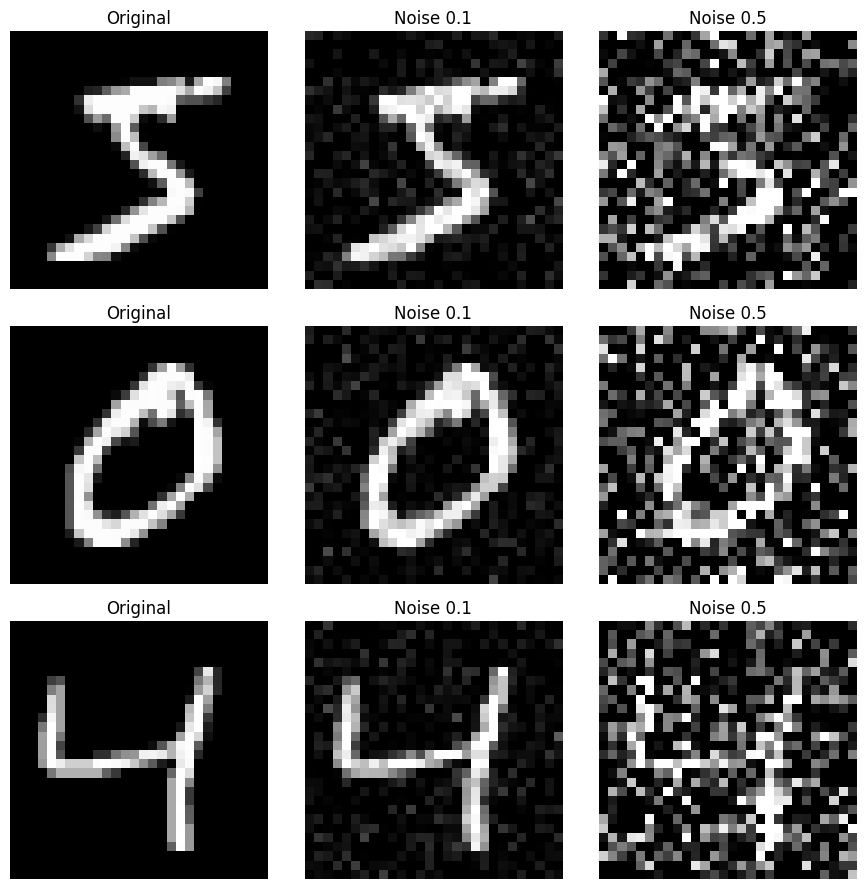

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# 1. Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# 2. Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# 3. Reshape to (28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# 4. Add Gaussian noise
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

x_train_noisy_high = x_train + noise_factor_high * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape)

x_test_noisy_high = x_test + noise_factor_high * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape)

# 5. Clip values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

# 6. Visualize images
n = 3  # number of images
plt.figure(figsize=(9, 9))

for i in range(n):
    # Original
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low Noise
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High Noise
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()

####Step 2: Build the Convolutional Denoising Autoencoder Model:

2.1 Tasks to Do:

• Encoder:

– Convolutional Layers + ReLU activation.

– Maxpooling to down-sample the features.

In [2]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [3]:
def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.
    """
    input_img = Input(shape=input_shape, name="input")

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)

    return input_img, encoded


• Decoder:

– Convolutional layers + ReLU activation.

– Upsampling to upsample the feature maps.

– Final Layer with sigmoid activation to keep output pixels in range [0, 1].


In [4]:
def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)

    return decoded

• Transpose
Convolutional is achieved in Keras using convolutional and Upsampling
operations.


In [5]:
def build_autoencoder():
    """
    Constructs and compiles the full autoencoder.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")

    autoencoder.compile(
        optimizer=Adam(),
        loss='binary_crossentropy'
    )

    return autoencoder

• Compile the Model with binary crossentropy loss and ADAM optimizer.

In [6]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

####Step 3: Train the Autoencoder:

3.1 Tasks to Do:

• Train the autoencoder using the noisy images as input and the clean images as the target.

• Monitor the training and validation loss during training.

In [7]:
# Build the autoencoder
autoencoder = build_autoencoder()

# Train using noisy input → clean target
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.1537 - val_loss: 0.1138
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.1098 - val_loss: 0.1056
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1042 - val_loss: 0.1017
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1014 - val_loss: 0.1002
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0997 - val_loss: 0.0984
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0985 - val_loss: 0.0972
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0975 - val_loss: 0.0965
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0968 - val_loss: 0.0960
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0961 - val_loss: 0.0954
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0957 - val_loss: 0.0950


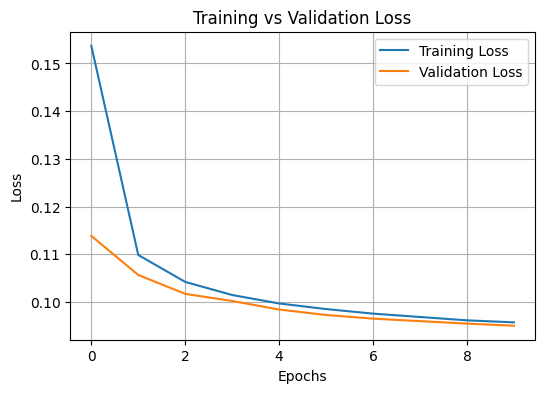

In [8]:
# Plot loss curves
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

###Step 4: Evaluate the Autoencoder:


####4.1 Tasks to Do:
• Use the trained autoencoder to predict the denoised images from the noisy test images.

• Display the original noisy images, the denoised images, and the clean images.

In [9]:
denoised_images = autoencoder.predict(x_test_noisy_high)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [10]:
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        # Denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        # Clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

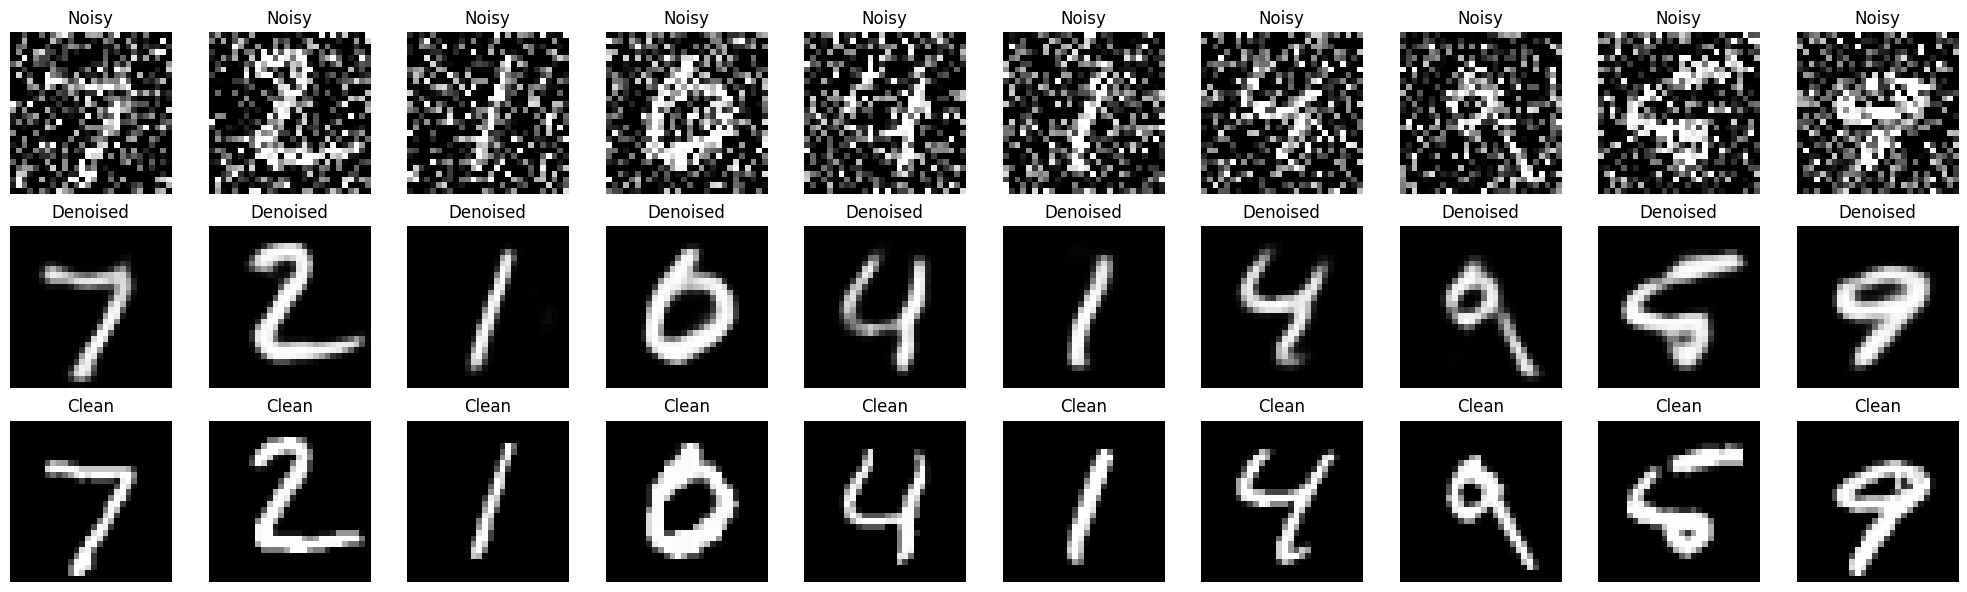

In [11]:
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

###4 Exercise: Build a Denoising Convolutional Autoencoder

Dataset: Devnagari Handwritten Digit Dataset:

####Step 1: Load & Preprocess Devnagari Dataset (using PIL)

In [2]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

# Path to dataset
data_path = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset"

images = []

# Load images using PIL
for folder_type in os.listdir(data_path):
    type_path = os.path.join(data_path, folder_type)

    if os.path.isdir(type_path):
        for digit_folder in os.listdir(type_path):
            digit_folder_path = os.path.join(type_path, digit_folder)

            if os.path.isdir(digit_folder_path):
                for file_name in os.listdir(digit_folder_path):
                    img_path = os.path.join(digit_folder_path, file_name)

                    # Check if the path is a file before trying to open it as an image
                    if os.path.isfile(img_path):
                        img = Image.open(img_path).convert('L')   # grayscale
                        img = img.resize((28, 28))                # standard size

                        img = np.array(img) / 255.0               # normalize
                        images.append(img)

# Convert to numpy array
images = np.array(images)

# Reshape → (samples, 28, 28, 1)
images = images.reshape(-1, 28, 28, 1)

print("Dataset shape:", images.shape)

Dataset shape: (20000, 28, 28, 1)


####Step 2: Train-Test Split

In [3]:
x_train, x_val = train_test_split(images, test_size=0.2, random_state=42)

####Step 3: Add Noise

In [27]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

x_val_noisy = x_val + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_val.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_val_noisy = np.clip(x_val_noisy, 0., 1.)

####Step 4: Build Autoencoder (4+ layers)

In [28]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_autoencoder():
    input_img = Input(shape=(28, 28, 1))

    # Encoder
    x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2,2), padding='same')(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2,2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2,2))(x)

    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)

    decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

    model = Model(input_img, decoded)
    model.compile(optimizer=Adam(), loss='binary_crossentropy')

    return model

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

####Step 5: Train Model

In [29]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.3054 - val_loss: 0.2196
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2098 - val_loss: 0.2036
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2010 - val_loss: 0.2001
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1965 - val_loss: 0.1963
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1938 - val_loss: 0.1925
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1914 - val_loss: 0.1901
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1895 - val_loss: 0.1895
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1885 - val_loss: 0.1883
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1872 - val_loss: 0.1864
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1858 - val_loss: 0.1859
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1851 - val_loss: 0.1853
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/ste

####Step 6: Plot Loss Curve

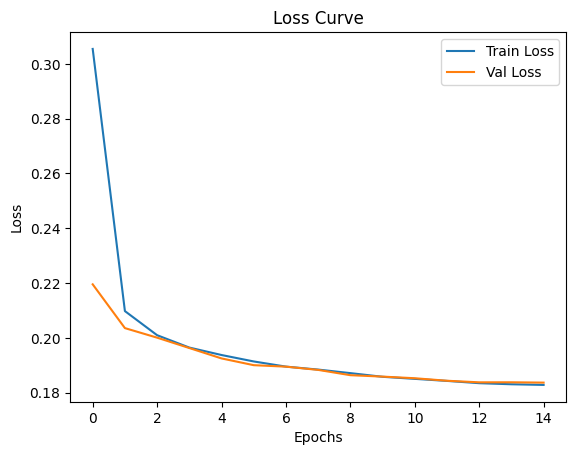

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

####Step 7: Evaluate & Visualize Results

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


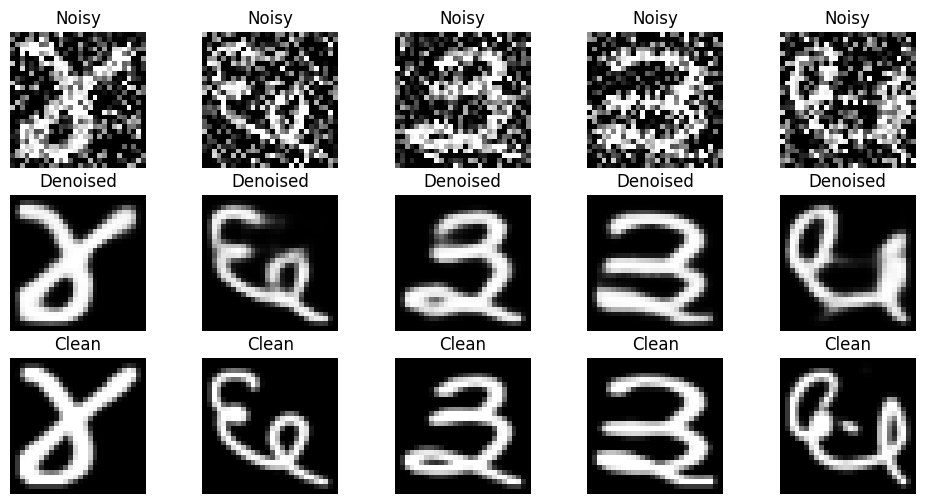

In [24]:
denoised = autoencoder.predict(x_val_noisy)

def plot_results(noisy, denoised, clean, n=5):
    plt.figure(figsize=(12,6))

    for i in range(n):
        # Noisy
        plt.subplot(3, n, i+1)
        plt.imshow(noisy[i].reshape(28,28), cmap='gray')
        plt.axis('off')
        plt.title("Noisy")

        # Denoised
        plt.subplot(3, n, i+1+n)
        plt.imshow(denoised[i].reshape(28,28), cmap='gray')
        plt.axis('off')
        plt.title("Denoised")

        # Clean
        plt.subplot(3, n, i+1+2*n)
        plt.imshow(clean[i].reshape(28,28), cmap='gray')
        plt.axis('off')
        plt.title("Clean")

    plt.show()

plot_results(x_val_noisy, denoised, x_val)

####Experiment and Fine - Tune the Model:

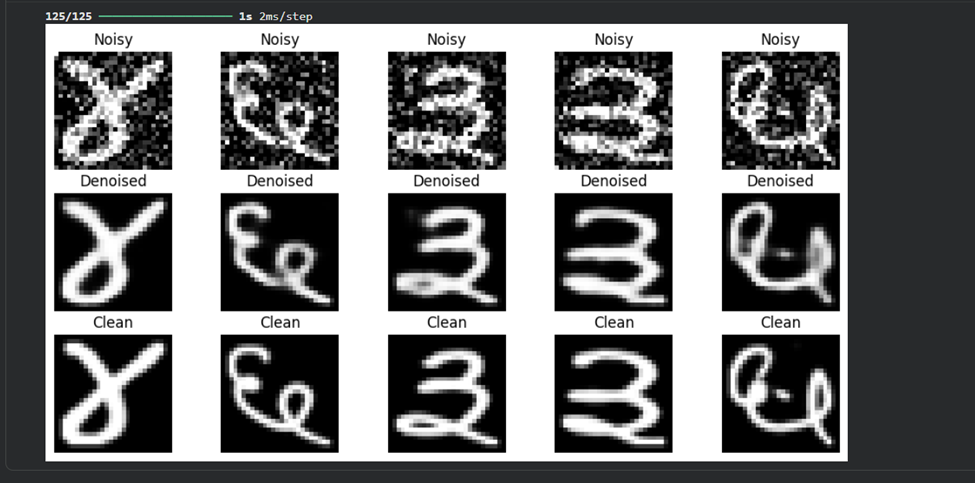

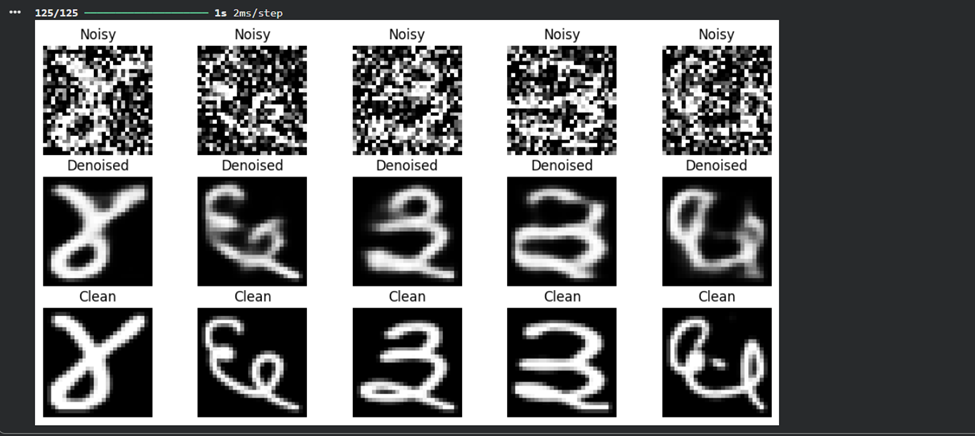

When experimenting with different noise levels, the performance of the denoising autoencoder varies significantly. At a noise factor of 0.3, the images contain minor distortions, allowing the model to reconstruct outputs that are sharp and close to the original. With a noise level of 0.5, the images become more corrupted, leading to slightly blurred reconstructions where some fine details are lost. At a high noise factor of 0.7, the images are heavily distorted, making it difficult for the model to learn meaningful features, resulting in blurry and less accurate outputs. Overall, increasing noise reduces reconstruction quality and model effectiveness.

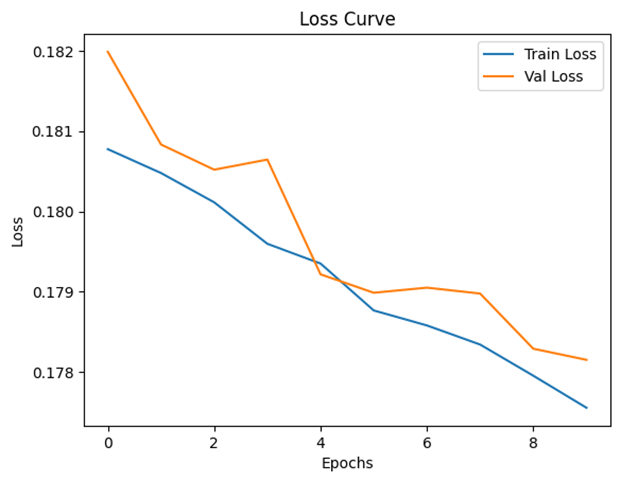

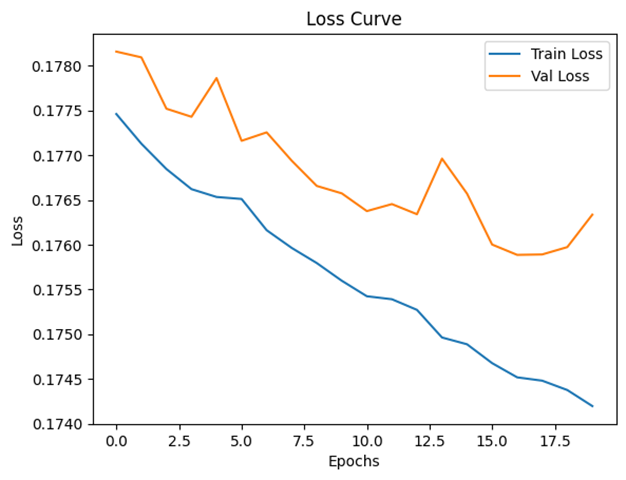

The loss curves show how the number of epochs affects model performance. With 10 epochs, both training and validation loss are still decreasing, indicating the model is underfitting and has not learned enough. At 15 epochs, the losses stabilize and remain close to each other, showing good learning and generalization without overfitting. With 20 epochs, training loss continues to decrease, but validation loss fluctuates and slightly increases, indicating overfitting as the model memorizes training data. Overall, 15 epochs provide the best balance, allowing the model to learn effectively while maintaining strong performance on unseen data.

Filters in a convolutional autoencoder are adjusted by changing the number in the Conv2D layers. Increasing the number of filters (e.g., from 32 to 64 or 128) allows the model to learn more complex features, improving reconstruction quality but increasing training time and computational cost. Decreasing filters (e.g., from 64 to 32 or 16) makes the model faster and more efficient but may reduce its ability to capture important details, leading to poorer outputs. It is important to balance filter size in both encoder and decoder. A moderate configuration, such as 32 and 64 filters, typically provides a good trade-off between performance and efficiency.